# 📦 Análise Exploratória — Olist E-Commerce
**Dataset:** Brazilian E-Commerce Public Dataset by Olist (Kaggle)  
**Período:** 2016 – 2018  
**Objetivo:** Entender o comportamento de vendas, satisfação do cliente e performance de entrega.

---

## 1. Importações e configurações

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 2. Carregando os dados

> ⚠️ Ajuste o caminho `DATA_PATH` para a pasta onde você extraiu os arquivos do Kaggle.

In [2]:
DATA_PATH = './data/'  # <-- altere se necessário

orders        = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
order_items   = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
customers     = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
payments      = pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
reviews       = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')
products      = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
category_transl = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')

print('Arquivos carregados!')
print(f'  Pedidos:       {orders.shape[0]:,} linhas')
print(f'  Itens:         {order_items.shape[0]:,} linhas')
print(f'  Clientes:      {customers.shape[0]:,} linhas')
print(f'  Pagamentos:    {payments.shape[0]:,} linhas')
print(f'  Avaliações:    {reviews.shape[0]:,} linhas')
print(f'  Produtos:      {products.shape[0]:,} linhas')

Arquivos carregados!
  Pedidos:       99,441 linhas
  Itens:         112,650 linhas
  Clientes:      99,441 linhas
  Pagamentos:    103,886 linhas
  Avaliações:    99,224 linhas
  Produtos:      32,951 linhas


## 3. Limpeza e tratamento dos dados

In [3]:
# Converter colunas de data
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Manter apenas pedidos entregues
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

# Calcular dias de entrega e atraso
orders_delivered['delivery_days'] = (
    orders_delivered['order_delivered_customer_date'] -
    orders_delivered['order_purchase_timestamp']
).dt.days

orders_delivered['delay_days'] = (
    orders_delivered['order_delivered_customer_date'] -
    orders_delivered['order_estimated_delivery_date']
).dt.days

orders_delivered['is_late'] = orders_delivered['delay_days'] > 0

# Coluna de ano-mês para séries temporais
orders_delivered['year_month'] = orders_delivered['order_purchase_timestamp'].dt.to_period('M')

print(f'Pedidos entregues: {orders_delivered.shape[0]:,}')
print(f'Nulos em delivery_days: {orders_delivered["delivery_days"].isna().sum()}')
orders_delivered[['delivery_days', 'delay_days', 'is_late']].describe()

Pedidos entregues: 96,478
Nulos em delivery_days: 8


,delivery_days,delay_days
count,96470.000000,96470.000000
mean,12.093604,-11.875889
std,9.551380,10.182105
min,0.000000,-147.000000
25%,6.000000,-17.000000
50%,10.000000,-12.000000
75%,15.000000,-7.000000
max,209.000000,188.000000


## 4. Pergunta 1: Quantos pedidos por mês? Houve sazonalidade?

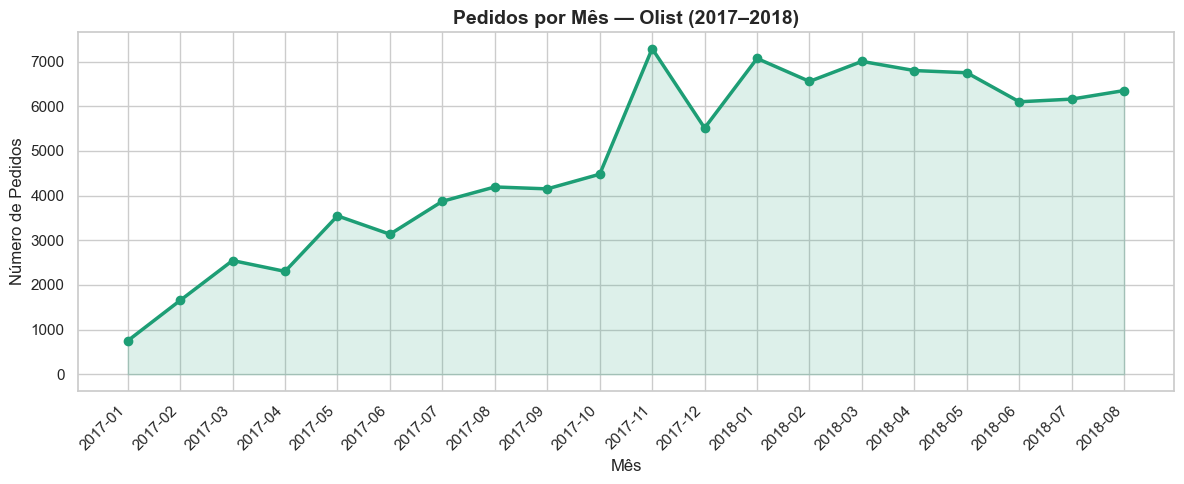


📌 Insight:
  Mês com mais pedidos: 2017-11
  Pico de pedidos: 7,289


In [4]:
monthly_orders = (
    orders_delivered
    .groupby('year_month')['order_id']
    .count()
    .reset_index()
    .rename(columns={'order_id': 'total_pedidos'})
)
# Filtrar período com dados completos
monthly_orders = monthly_orders[
    (monthly_orders['year_month'] >= '2017-01') &
    (monthly_orders['year_month'] <= '2018-08')
]

fig, ax = plt.subplots()
ax.plot(
    monthly_orders['year_month'].astype(str),
    monthly_orders['total_pedidos'],
    marker='o', linewidth=2.5, color='#1D9E75'
)
ax.fill_between(
    monthly_orders['year_month'].astype(str),
    monthly_orders['total_pedidos'],
    alpha=0.15, color='#1D9E75'
)
ax.set_title('Pedidos por Mês — Olist (2017–2018)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Número de Pedidos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('grafico_pedidos_mes.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 Insight:')
print(f'  Mês com mais pedidos: {monthly_orders.loc[monthly_orders["total_pedidos"].idxmax(), "year_month"]}')
print(f'  Pico de pedidos: {monthly_orders["total_pedidos"].max():,}')

## 5. Pergunta 2: Quais estados compram mais?

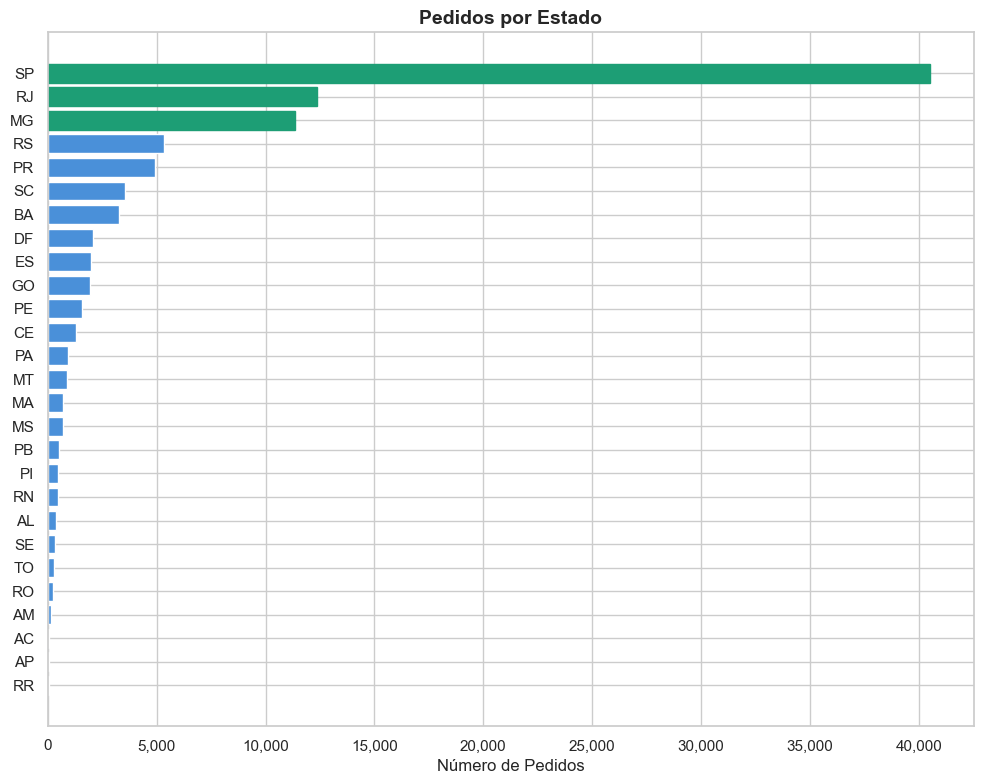


📌 Top 3 estados:
customer_state  total_pedidos
            SP          40501
            RJ          12350
            MG          11354


In [5]:
# Merge pedidos com clientes
df_state = orders_delivered.merge(customers[['customer_id', 'customer_state']], on='customer_id')

state_orders = (
    df_state.groupby('customer_state')['order_id']
    .count()
    .reset_index()
    .rename(columns={'order_id': 'total_pedidos'})
    .sort_values('total_pedidos', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(state_orders['customer_state'], state_orders['total_pedidos'], color='#4A90D9')
# Destaque top 3
for bar in bars[-3:]:
    bar.set_color('#1D9E75')

ax.set_title('Pedidos por Estado', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Pedidos')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('grafico_pedidos_estado.png', dpi=150, bbox_inches='tight')
plt.show()

top3 = state_orders.tail(3)[['customer_state', 'total_pedidos']].iloc[::-1]
print('\n📌 Top 3 estados:')
print(top3.to_string(index=False))

## 6. Pergunta 3: Qual a nota média de avaliação? Atrasos afetam a nota?

⭐ Nota média geral: 4.16

  No prazo:   4.29
  Atrasado:   2.27


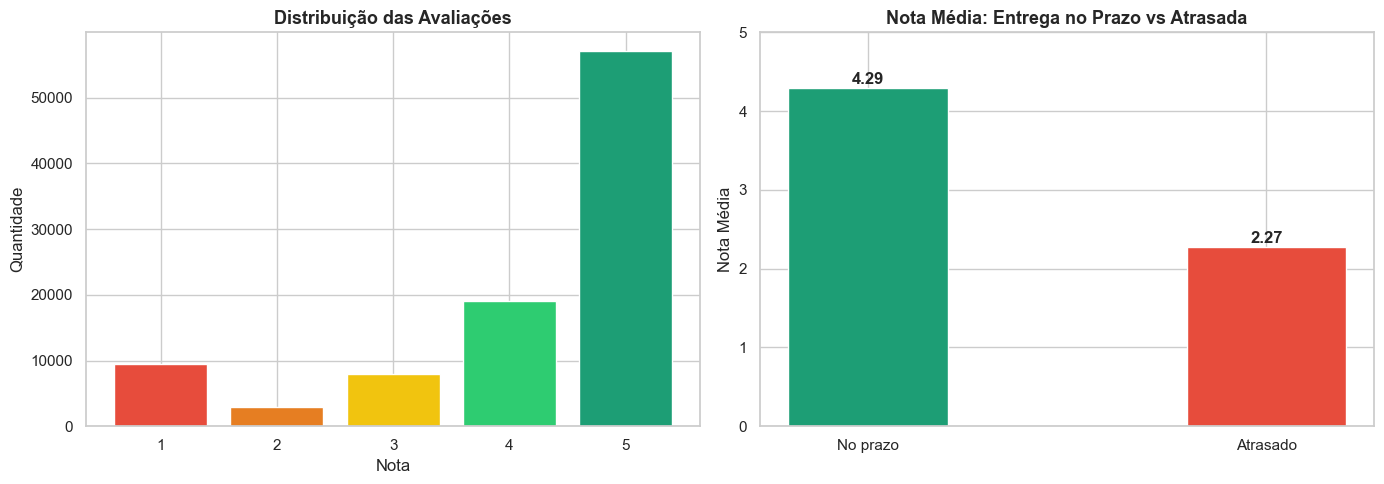

In [6]:
# Merge pedidos entregues com avaliações
df_reviews = orders_delivered.merge(
    reviews[['order_id', 'review_score']], on='order_id', how='left'
)

avg_score = df_reviews['review_score'].mean()
print(f'⭐ Nota média geral: {avg_score:.2f}')

# Nota média por: pedido no prazo vs atrasado
score_by_late = df_reviews.groupby('is_late')['review_score'].mean()
print(f'\n  No prazo:   {score_by_late[False]:.2f}')
print(f'  Atrasado:   {score_by_late[True]:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição das notas
score_counts = df_reviews['review_score'].value_counts().sort_index()
axes[0].bar(score_counts.index, score_counts.values, color=['#E74C3C','#E67E22','#F1C40F','#2ECC71','#1D9E75'])
axes[0].set_title('Distribuição das Avaliações', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nota')
axes[0].set_ylabel('Quantidade')

# Nota média: prazo vs atraso
labels = ['No prazo', 'Atrasado']
values = [score_by_late[False], score_by_late[True]]
colors = ['#1D9E75', '#E74C3C']
axes[1].bar(labels, values, color=colors, width=0.4)
axes[1].set_ylim(0, 5)
axes[1].set_title('Nota Média: Entrega no Prazo vs Atrasada', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Nota Média')
for i, v in enumerate(values):
    axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('grafico_avaliacoes.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Pergunta 4: Qual forma de pagamento é mais usada?

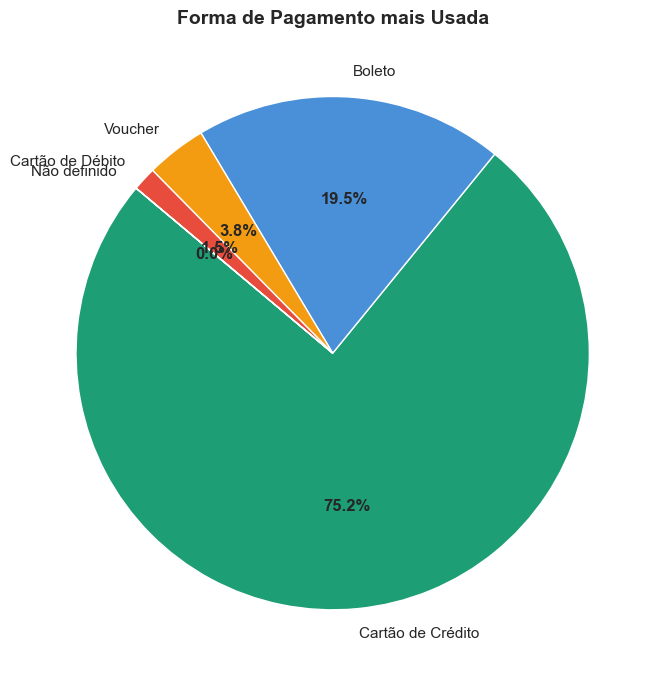

In [7]:
payment_counts = (
    payments.groupby('payment_type')['order_id']
    .nunique()
    .reset_index()
    .rename(columns={'order_id': 'total'})
    .sort_values('total', ascending=False)
)

# Tradução dos tipos
traducao = {
    'credit_card': 'Cartão de Crédito',
    'boleto': 'Boleto',
    'voucher': 'Voucher',
    'debit_card': 'Cartão de Débito',
    'not_defined': 'Não definido'
}
payment_counts['payment_type'] = payment_counts['payment_type'].map(traducao).fillna(payment_counts['payment_type'])

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    payment_counts['total'],
    labels=payment_counts['payment_type'],
    autopct='%1.1f%%',
    colors=['#1D9E75','#4A90D9','#F39C12','#E74C3C','#95A5A6'],
    startangle=140
)
for text in autotexts:
    text.set_fontweight('bold')
ax.set_title('Forma de Pagamento mais Usada', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_pagamentos.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Pergunta 5: Quais categorias de produto mais vendem?

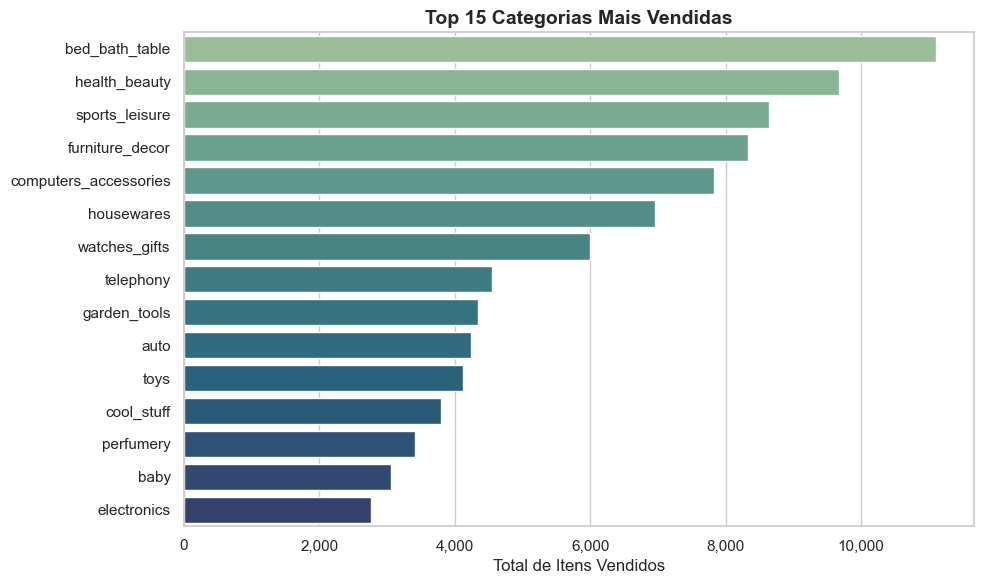


📌 Top 5 categorias:
            categoria  total_vendas
       bed_bath_table         11115
        health_beauty          9670
       sports_leisure          8641
      furniture_decor          8334
computers_accessories          7827


In [8]:
# Merge itens → produtos → tradução
df_cat = (
    order_items
    .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
    .merge(category_transl, on='product_category_name', how='left')
)

top_categories = (
    df_cat.groupby('product_category_name_english')['order_id']
    .count()
    .reset_index()
    .rename(columns={'order_id': 'total_vendas', 'product_category_name_english': 'categoria'})
    .sort_values('total_vendas', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_categories, y='categoria', x='total_vendas', palette='crest', ax=ax)
ax.set_title('Top 15 Categorias Mais Vendidas', fontsize=14, fontweight='bold')
ax.set_xlabel('Total de Itens Vendidos')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('grafico_categorias.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 Top 5 categorias:')
print(top_categories.head(5)[['categoria', 'total_vendas']].to_string(index=False))

## 9. Exportar dados tratados para o Looker Studio

> Gera CSVs limpos que você vai subir no Google Sheets para construir o dashboard.

In [9]:
# 1. Pedidos por mês
monthly_orders.to_csv('export_pedidos_mes.csv', index=False)

# 2. Pedidos por estado
state_orders.to_csv('export_pedidos_estado.csv', index=False)

# 3. Avaliações com flag de atraso
df_reviews[['order_id','delivery_days','delay_days','is_late','review_score']].to_csv(
    'export_avaliacoes.csv', index=False
)

# 4. Pagamentos
payment_counts.to_csv('export_pagamentos.csv', index=False)

# 5. Categorias
top_categories.to_csv('export_categorias.csv', index=False)

print('✅ 5 arquivos exportados com sucesso!')
print('Suba esses CSVs no Google Sheets e conecte ao Looker Studio.')

✅ 5 arquivos exportados com sucesso!
Suba esses CSVs no Google Sheets e conecte ao Looker Studio.


## 10. Resumo dos principais insights

Complete esta seção com os números reais que você encontrou ao rodar o notebook:

| Insight | Valor |
|---|---|
| Total de pedidos entregues | 96.478 |
| Mês com mais pedidos | Novembro/2017(Black Friday) |
| Estado que mais compra | SP(40.501 pedidos) |
| Nota média geral | 4.16 |
| Queda de nota em atrasos | 2 pontos (4.29 -> 2.27) |
| Forma de pagamento #1 | Cartão de Crédito(75.2%) |
| Categoria mais vendida | Cama, Mesa e banho (11.115) |

---
*Análise feita por [Dione Dias] — github.com/dionesantoss/olist-ecommerce-analysis*